# 2018 Fannie Mae SF Loan Analysis

This Jupyter Notebook analyzes SF loans dataset in order to illustrate working with Python Data Analysis Tools. I will be examining the Purpose of the Loan properties ("Refinance vs Purchase)
For the dataset please see: fhlmc_sf2018d_loans.txt
For explanations on the Dataset, please see: 2018_Single_Family_National_File_C
Source: https://www.kaggle.com/datasets/jeromeblanchet/fannie-mae-freddie-mac-public-use-database

# Imports and Data Cleaning

In [92]:
# Regular imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from webencodings import labels


In [93]:
df = pd.read_csv('./data/fnma_sf2018d_loans.txt', sep=r'\s+', index_col=False, header=None)

In [94]:
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1,1,2,2,2,1,2,1,4,1,102000,2,2,2,1,0.0
1,1,2,3,2,3,2,2,1,2,1,425000,4,3,3,1,0.0
2,1,3,3,2,2,5,1,1,3,1,220000,4,1,1,1,0.0
3,1,4,3,2,2,5,1,1,4,1,233000,3,1,1,1,0.0
4,1,5,3,1,2,5,1,1,3,1,195000,3,1,1,1,0.0


Since there are no column names, we'll add them using the information from the pdf

In [95]:
column_names = ["Enterprise Flag", "Record Number", "2010 Census Tract - Percent Minority", "Tract Income Ratio", "Borrower Income Ratio", "LTV Ratio", "Purpose of Loan", "Federal Guarantee", "Credit Score", "Product Type", "Purchase Price", "Interest Rate at Origination", "Term of Mortgage at Origination", "Amortization Term", "Portfolio Flag", "Percent Repurchased"]

In [96]:
df.columns = column_names

In [97]:
df.head()

,Enterprise Flag,Record Number,2010 Census Tract - Percent Minority,Tract Income Ratio,Borrower Income Ratio,LTV Ratio,Purpose of Loan,Federal Guarantee,Credit Score,Product Type,Purchase Price,Interest Rate at Origination,Term of Mortgage at Origination,Amortization Term,Portfolio Flag,Percent Repurchased
0,1,1,2,2,2,1,2,1,4,1,102000,2,2,2,1,0.0
1,1,2,3,2,3,2,2,1,2,1,425000,4,3,3,1,0.0
2,1,3,3,2,2,5,1,1,3,1,220000,4,1,1,1,0.0
3,1,4,3,2,2,5,1,1,4,1,233000,3,1,1,1,0.0
4,1,5,3,1,2,5,1,1,3,1,195000,3,1,1,1,0.0


Some basic stats:

In [98]:
df.describe()

,Enterprise Flag,Record Number,2010 Census Tract - Percent Minority,Tract Income Ratio,Borrower Income Ratio,LTV Ratio,Purpose of Loan,Federal Guarantee,Credit Score,Product Type,Purchase Price,Interest Rate at Origination,Term of Mortgage at Origination,Amortization Term,Portfolio Flag,Percent Repurchased
count,83836.0,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000,8.383600e+04,83836.000000,83836.000000,83836.000000,83836.000000,83836.000000
mean,1.0,41918.500000,2.347297,1.953421,2.533267,3.421764,1.237320,1.000072,3.322523,1.001622,2.222880e+05,4.300301,1.168865,1.168865,1.089771,0.047002
std,0.0,24201.512921,0.746548,0.754076,0.798715,1.372592,0.425443,0.008460,1.040816,0.040244,1.502645e+05,1.153851,0.505193,0.505193,0.285854,0.196696
min,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.400000e+04,1.000000,1.000000,1.000000,1.000000,0.000000
25%,1.0,20959.750000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.230000e+05,4.000000,1.000000,1.000000,1.000000,0.000000
50%,1.0,41918.500000,3.000000,2.000000,3.000000,4.000000,1.000000,1.000000,3.000000,1.000000,1.850000e+05,4.000000,1.000000,1.000000,1.000000,0.000000
75%,1.0,62877.250000,3.000000,2.000000,3.000000,5.000000,1.000000,1.000000,4.000000,1.000000,2.820000e+05,5.000000,1.000000,1.000000,1.000000,0.000000
max,1.0,83836.000000,9.000000,9.000000,9.000000,5.000000,2.000000,2.000000,9.000000,2.000000,3.955000e+06,7.000000,3.000000,3.000000,2.000000,1.000000


In [99]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 83836 entries, 0 to 83835
Data columns (total 16 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Enterprise Flag                       83836 non-null  int64  
 1   Record Number                         83836 non-null  int64  
 2   2010 Census Tract - Percent Minority  83836 non-null  int64  
 3   Tract Income Ratio                    83836 non-null  int64  
 4   Borrower Income Ratio                 83836 non-null  int64  
 5   LTV Ratio                             83836 non-null  int64  
 6   Purpose of Loan                       83836 non-null  int64  
 7   Federal Guarantee                     83836 non-null  int64  
 8   Credit Score                          83836 non-null  int64  
 9   Product Type                          83836 non-null  int64  
 10  Purchase Price                        83836 non-null  int64  
 11  Interest Rate at Originati

Next I want to remove any rows that have data that is either missing or not available

In [100]:
df = df[(df["2010 Census Tract - Percent Minority"] != 9)
        & (df["Tract Income Ratio"] != 9)
        & (df["LTV Ratio"] != 9)
        & (df["Credit Score"] != 9)
        & (df["Product Type"] != 9)
        & (df["Purchase Price"] != 999999999)
        & (df["Interest Rate at Origination"] != 99)
        & (df["Term of Mortgage at Origination"] != 9)
        & (df["Amortization Term"] != 9)
        & (df["Percent Repurchased"] != 9999.0)]

In [101]:
df.count() #Looks like the above removed 164 columns

Enterprise Flag                         83672
Record Number                           83672
2010 Census Tract - Percent Minority    83672
Tract Income Ratio                      83672
Borrower Income Ratio                   83672
LTV Ratio                               83672
Purpose of Loan                         83672
Federal Guarantee                       83672
Credit Score                            83672
Product Type                            83672
Purchase Price                          83672
Interest Rate at Origination            83672
Term of Mortgage at Origination         83672
Amortization Term                       83672
Portfolio Flag                          83672
Percent Repurchased                     83672
dtype: int64

In [102]:
#Dropping the Enterprise Flag Column since this is all Fannie Mae data
df.drop(labels="Enterprise Flag", axis=1, inplace=True)

In [103]:
df.head()

,Record Number,2010 Census Tract - Percent Minority,Tract Income Ratio,Borrower Income Ratio,LTV Ratio,Purpose of Loan,Federal Guarantee,Credit Score,Product Type,Purchase Price,Interest Rate at Origination,Term of Mortgage at Origination,Amortization Term,Portfolio Flag,Percent Repurchased
0,1,2,2,2,1,2,1,4,1,102000,2,2,2,1,0.0
1,2,3,2,3,2,2,1,2,1,425000,4,3,3,1,0.0
2,3,3,2,2,5,1,1,3,1,220000,4,1,1,1,0.0
3,4,3,2,2,5,1,1,4,1,233000,3,1,1,1,0.0
4,5,3,1,2,5,1,1,3,1,195000,3,1,1,1,0.0


# Exploratory Data Analysis

[]

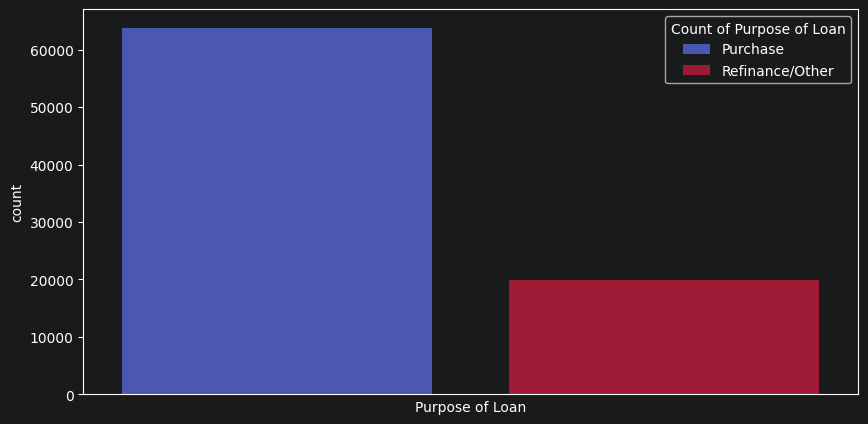

In [104]:
# Purchase vs Refinance

plt.figure(figsize=(10, 5))

ax = sns.countplot(df, x="Purpose of Loan", hue="Purpose of Loan", palette="coolwarm")
plt.legend(title = "Count of Purpose of Loan", labels=["Purchase", "Refinance/Other"])
ax.set_xticks([])


([<matplotlib.axis.XTick at 0x1af4e66a710>,
 [Text(0, 0, '<620'),
  Text(1, 0, '620-659'),
  Text(2, 0, '660-699'),
  Text(3, 0, '700-760'),
  Text(4, 0, '>760')])

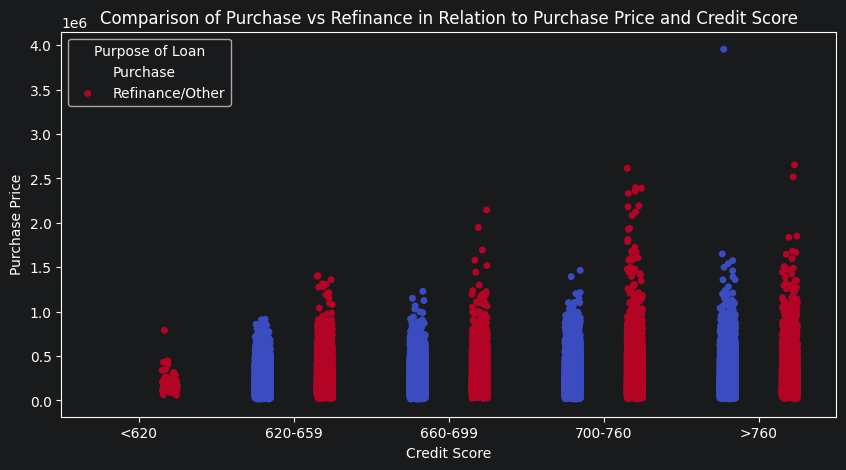

In [112]:
#Credit Score vs Purchase Price in relation to Purpose of the Loan
plt.figure(figsize=(10, 5))
ax = sns.stripplot(data = df, x="Credit Score", y="Purchase Price", hue="Purpose of Loan", palette="coolwarm", jitter=True, dodge=True)
plt.legend(title="Purpose of Loan",labels=["Purchase", "Refinance/Other"])
plt.title("Comparison of Purchase vs Refinance in Relation to Purchase Price and Credit Score")
plt.xticks(np.arange(5),["<620", "620-659", "660-699", "700-760", ">760"])
